# Semi-supervised clustering — must-link / cannot-link (COP-KMeans)

Sometimes geometry alone groups the data the "wrong" way for your task, but you know a few pairwise
facts: *these two belong together*, *those two must be apart*. Pass them as `must_link` /
`cannot_link` (row-index pairs) and `Betula` runs **COP-KMeans** (Wagstaff et al., 2001): the
constraints are honoured exactly, or an infeasible set raises rather than being silently violated.

```bash
pip install betula-cluster matplotlib seaborn pandas networkx scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs

from betula_cluster import Betula

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

## Four blobs in a 2×2 grid — an ambiguous grouping

The vertical gap (3) is smaller than the horizontal gap (4), so unconstrained `k=2` groups by
**column** (left vs right). Suppose our task needs **rows** (top vs bottom).

In [2]:
centers = [(0, 3), (4, 3), (0, 0), (4, 0)]  # top-left, top-right, bottom-left, bottom-right
X, quad = make_blobs(n_samples=1200, centers=centers, cluster_std=0.45, random_state=0)
X = X.astype(np.float64)
# one representative row index per quadrant (first point assigned to it)
rep = {q: int(np.flatnonzero(quad == q)[0]) for q in range(4)}
TL, TR, BL, BR = rep[0], rep[1], rep[2], rep[3]

plain = np.asarray(Betula(n_clusters=2, method="kmeans", threshold=0.1, seed=1).fit_predict(X))

## Add three constraints to force the row grouping

- **must-link** the two top blobs together, and the two bottom blobs together;
- **cannot-link** a top point from a bottom point.

In [3]:
must_link = [(TL, TR), (BL, BR)]
cannot_link = [(TL, BL)]
est = Betula(n_clusters=2, method="kmeans", threshold=0.1, seed=1)
est.fit(X, must_link=must_link, cannot_link=cannot_link)
constrained = np.asarray(est.predict(X))

## Before vs after

The same data, the same `k` — three labelled pairs flip the partition from columns to rows.

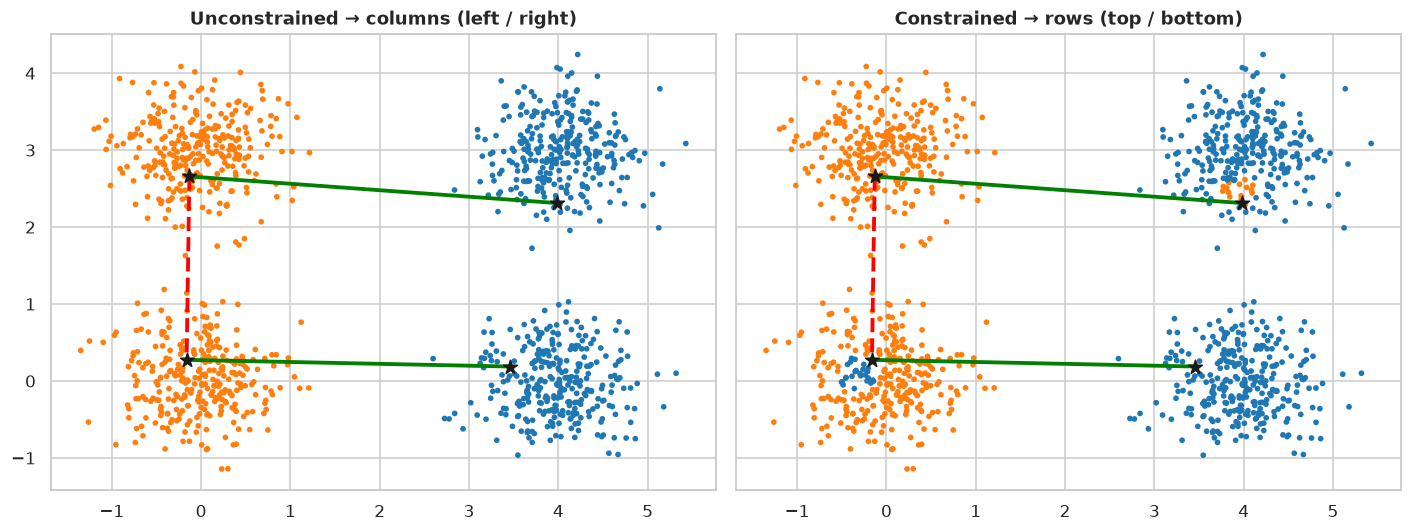

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, lab, title in [
    (axes[0], plain, "Unconstrained → columns (left / right)"),
    (axes[1], constrained, "Constrained → rows (top / bottom)"),
]:
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=lab, palette="tab10", s=14, linewidth=0, legend=False, ax=ax)
    ax.set_title(title)
# overlay the constraints
for ax in axes:
    for i, j in must_link:
        ax.plot(*X[[i, j]].T, "-", c="green", lw=2.5)
    for i, j in cannot_link:
        ax.plot(*X[[i, j]].T, "--", c="red", lw=2.5)
    ax.scatter(*X[[TL, TR, BL, BR]].T, c="k", s=90, marker="*", zorder=5)
axes[0].set(xlabel="", ylabel="")
plt.tight_layout()
plt.show()

## The constraint graph

Must-link edges (green) form groups that are assigned together; cannot-link edges (red, dashed) keep
groups apart. `betula-cluster` translates these point constraints to the microcluster level.

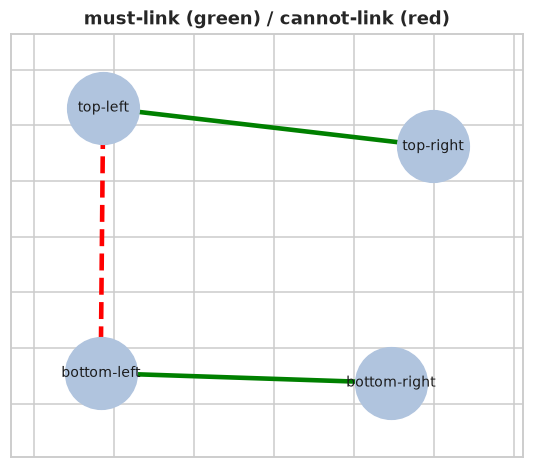

In [5]:
g = nx.Graph()
names = {TL: "top-left", TR: "top-right", BL: "bottom-left", BR: "bottom-right"}
for idx, name in names.items():
    g.add_node(name, pos=(float(X[idx, 0]), float(X[idx, 1])))
g.add_edges_from([(names[i], names[j], {"kind": "must"}) for i, j in must_link])
g.add_edges_from([(names[i], names[j], {"kind": "cannot"}) for i, j in cannot_link])
pos = nx.get_node_attributes(g, "pos")
fig, ax = plt.subplots(figsize=(6, 5))
nx.draw_networkx_nodes(g, pos, node_color="lightsteelblue", node_size=2200, ax=ax)
nx.draw_networkx_labels(g, pos, font_size=9, ax=ax)
must_e = [(u, v) for u, v, d in g.edges(data=True) if d["kind"] == "must"]
cannot_e = [(u, v) for u, v, d in g.edges(data=True) if d["kind"] == "cannot"]
nx.draw_networkx_edges(g, pos, edgelist=must_e, edge_color="green", width=3, ax=ax)
nx.draw_networkx_edges(g, pos, edgelist=cannot_e, edge_color="red", width=3, style="dashed", ax=ax)
ax.set_title("must-link (green) / cannot-link (red)")
ax.margins(0.2)
plt.show()

## Infeasible constraints raise — never silently violated

Three mutually cannot-linked points need three clusters; asking for `k=2` is impossible, so it
raises `ValueError` (likewise a cannot-link between two points the tree merged into one
microcluster — lower `threshold` to separate them).

In [6]:
try:
    Betula(n_clusters=2, method="kmeans", threshold=0.1).fit(
        X, cannot_link=[(TL, TR), (TL, BL), (TR, BL)]
    )
    print("no error (unexpected)")
except ValueError as e:
    print("ValueError:", e)

ValueError: constraints are infeasible at this n_clusters: increase n_clusters or relax cannot-links
